# Subsidy capitalisation in a migration model

**Research question.** How large a subsidy must a state offer residents to sustain net in-migration once rent feedback is accounted for, and how does this depend on housing supply elasticity? The policy state is Ohio.

**Status: work in progress.** Parameters are placeholders and have not been calibrated. Money is in $k per year.

**Contents**

1. Introduction and setup
2. Data
3. Model
4. Validation (baseline run, comparison with observed migration, unit tests)
5. Experiments
6. Results *(to be completed)*
7. Discussion and limitations *(to be completed)*
8. Interactive demonstration

## 1. Introduction and setup

When people move into a state, demand for housing rises and so does rent. A state that subsidises residents to attract them may therefore see part of the subsidy absorbed by higher rent (capitalisation). The model below represents individual agents choosing among 8 U.S. states, with rent responding to population through a housing supply elasticity, and uses it to study how large a subsidy is needed and how this depends on housing supply.

This differs from Schelling-style models, in which agents move in response to their neighbours and nothing else changes. Here agents respond to prices that their own collective movement changes.

In [1]:
import sys, subprocess
from dataclasses import replace
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make the project importable whether this runs from notebooks/ or the project root.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.model import MigrationModel
from src.params import Params
from utils.data import load_initial_state
from utils.metrics import simulated_net_migration_per_1000, observed_net_migration_per_1000

## 2. Data

Real 2010 state data initialises the model. Observed migration is held back and used only to check the baseline.

### 2.1 (Optional) Re-download the data

The CSV files in `data/` are already included, so **this step is not needed to run the notebook**. To regenerate them from the U.S. Census API, get a free key from <https://api.census.gov/data/key_signup.html>, save it in a `.env` file in the project root as `CENSUS_API_KEY=<your key>`, set `REFRESH_DATA = True` below and run the cell.

In [2]:
REFRESH_DATA = False

if REFRESH_DATA:
    subprocess.run([sys.executable, "-m", "utils.fetch_census"], cwd=ROOT, check=True)
else:
    print("Skipping download; using the CSV files already in data/.")

Skipping download; using the CSV files already in data/.


### 2.2 Initial conditions

Eight states chosen to contrast growth and housing costs. Population is used only to allocate agents to states in proportion; rent and income are 2010 ACS medians converted to $k per year.

In [3]:
init = load_initial_state(ROOT / "data" / "initial_state_2010.csv")
pd.DataFrame({"population": init.population, "rent ($k/yr)": init.rent, "income ($k/yr)": init.wage},
             index=init.names).round(1)

,population,rent ($k/yr),income ($k/yr)
California,37349363.0,14.0,57.7
New York,19392283.0,12.2,54.1
Illinois,12843166.0,10.2,53.0
Ohio,11536182.0,8.2,45.1
Texas,25257114.0,9.6,48.6
Florida,18843326.0,11.4,44.4
Colorado,5049071.0,10.4,54.0
North Carolina,9561558.0,8.8,43.3


## 3. Model

Each year a random fraction of the $N$ agents reconsider where to live. Agent $i$ with income multiplier $z_i$ values state $j$ at

$$u_{ij} = z_i\, w_j - r_j + s_j + \tau\, \frac{n_j}{N} - c\,\mathbf{1}[j \ne \text{current state}]$$

where $w_j$ is the state wage, $r_j$ rent, $s_j$ the subsidy (non-zero only in the policy state), $n_j/N$ the state's population share (social ties, strength $\tau$) and $c$ the migration cost. The agent picks state $j$ with probability $\propto e^{\beta u_{ij}}$.

After everyone has chosen, rent responds to the population change with housing supply elasticity $\varepsilon$:

$$r_j^{t+1} = r_j^{t}\left(\frac{n_j^{t+1}}{n_j^{t}}\right)^{1/\varepsilon}$$

A low $\varepsilon$ means rent rises sharply when people move in, so part of any subsidy is absorbed by rent (capitalisation).

## 4. Validation

### 4.1 A single baseline run (no subsidy)

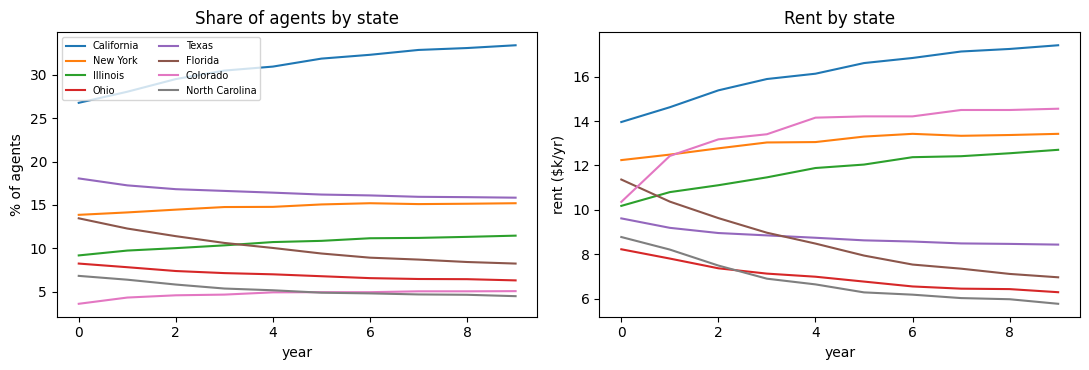

In [4]:
params = Params(n_years=9, seed=0)
h = MigrationModel(params, init).run()

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
share = h.population / h.population.sum(axis=1, keepdims=True) * 100
for j, name in enumerate(init.names):
    ax[0].plot(share[:, j], label=name)
    ax[1].plot(h.rent[:, j])
ax[0].set(title="Share of agents by state", xlabel="year", ylabel="% of agents")
ax[1].set(title="Rent by state", xlabel="year", ylabel="rent ($k/yr)")
ax[0].legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

### 4.2 Baseline check against observed migration

We compare the simulated cumulative net migration (per 1,000 residents, averaged over 10 seeds, 9 years to match 2010-11 to 2018-19) with the observed net domestic migration. The observed data is *not* used to set up the model. Only the ranking and direction are meaningful, since the simulated system is closed (migration sums to zero across states).

In [5]:
obs = observed_net_migration_per_1000(ROOT / "data" / "observed_net_migration.csv", init)
sim = np.mean([simulated_net_migration_per_1000(
    MigrationModel(replace(params, seed=s), init).run(), params.n_agents) for s in range(10)], axis=0)

cmp = pd.DataFrame({"observed per 1000": obs, "simulated per 1000": sim}, index=init.names).round(1)
print("Spearman rank correlation:", round(cmp.corr(method="spearman").iloc[0, 1], 2))
cmp

Spearman rank correlation: -0.67


,observed per 1000,simulated per 1000
California,-23.9,68.9
New York,-70.0,16.1
Illinois,-66.4,21.3
Ohio,-18.1,-20.1
Texas,44.2,-21.0
Florida,67.9,-54.6
Colorado,68.5,14.4
North Carolina,47.6,-24.9


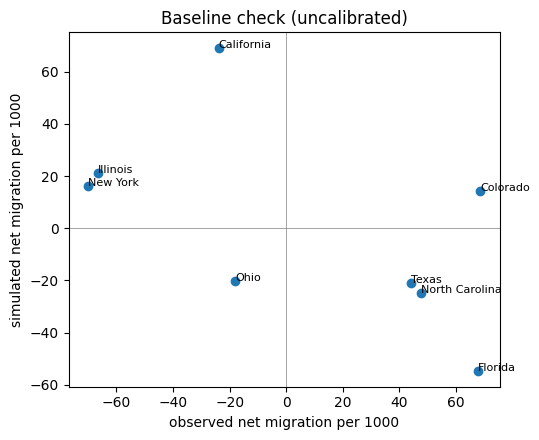

In [6]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.scatter(cmp["observed per 1000"], cmp["simulated per 1000"])
for name, row in cmp.iterrows():
    ax.annotate(name, (row["observed per 1000"], row["simulated per 1000"]), fontsize=8)
ax.axhline(0, c="grey", lw=.5); ax.axvline(0, c="grey", lw=.5)
ax.set(xlabel="observed net migration per 1000", ylabel="simulated net migration per 1000",
       title="Baseline check (uncalibrated)")
plt.tight_layout(); plt.show()

**Reading this.** With placeholder parameters the baseline does *not* reproduce the real pattern: states with high income net of rent (California, Colorado) attract agents in the model, whereas in reality the Sun Belt states gained and California, New York and Illinois lost. The model only contains wages, rent and ties, and omits other drivers such as jobs growth, climate and taxes. This is an honest limitation of the current version and a point for the next iteration.

### 4.3 Calibrating migration cost to the observed move rate

Published migration-cost estimates span an order of magnitude (about \$21,500 in Bayer and Juessen 2012 to about \$312,000 in Kennan and Walker 2011), because they come from forward-looking models, whereas our agents compare a one-off cost with a single year of utility difference. Instead we anchor the migration cost $c$ on the *realised move rate*: the share of agents changing state each year in the baseline (no subsidy). Molloy, Smith and Wozniak (2011) report about 1.65% per year from the CPS for 2001-2010 and about 2.8% from IRS data (roughly 1.5% across Census regions plus 1.3% within regions).

In [7]:
from utils.metrics import annual_move_rate

costs = [4, 5, 6, 7, 8, 9, 10]
rate = {c: np.mean([annual_move_rate(MigrationModel(Params(n_years=20, seed=s, migration_cost=c), init).run(),
                                      params.n_agents) for s in range(20)]) for c in costs}
pd.Series(rate, name="share of agents changing state per year").rename_axis("migration cost ($k)").map("{:.2%}".format).to_frame()

,share of agents changing state per year
migration cost ($k),
4,4.39%
5,3.49%
6,2.72%
7,2.08%
8,1.60%
9,1.24%
10,0.98%


A cost of **8** reproduces the CPS rate (1.6%) and is the default used throughout, and a cost of 6 reproduces the IRS rate (about 2.7%). The sensitivity analysis in section 6.3 includes both, as well as the earlier placeholder of 10, which gives only about 1.0%. The real rates apply to the whole population, while young adults move more often (2.2% for ages 25-44 and 3.0% for ages 18-24 in 2001-2010), so a somewhat higher rate would also be defensible.

### 4.4 Unit tests

The unit tests (conservation of agents, boundary cases, expected directions of effect) run with pytest.

In [8]:
r = subprocess.run([sys.executable, "-m", "pytest", "-q"], cwd=ROOT, capture_output=True, text=True)
print(r.stdout[-600:])

...................................                                      [100%]
35 passed in 1.71s



## 5. Experiments

### 5.1 Outcome measures

Every measure compares a run **with** the subsidy against a **control run with no subsidy at the same elasticity**, using the same random seeds (20 seeds, 20 years). Ohio shrinks even without a subsidy, so raw populations would mislead.

- **Population gain** $G$: the extra Ohio population at year $T$ caused by the subsidy, as a fraction of Ohio's initial population (0.10 = +10%).
- **Capitalisation share** $\kappa = (\bar r_{\text{subsidy}} - \bar r_{\text{control}})/s$: the fraction of the subsidy absorbed by higher rent at year $T$ (both in $k/yr).
- **Required subsidy** $s^*$: the smallest subsidy giving $G \ge$ a target (here +10%), found by bisection.

These are measured at a **fixed horizon** ($T = 20$) and not at a "settled" state, because with elastic housing supply the system does not settle: rent barely responds, so the population keeps drifting. `settling_change` reports how much the population was still changing over the last 5 years.

In [9]:
from utils.experiments import run_ensemble, required_subsidy_for_target
from utils.metrics import population_gain, capitalisation_share, settling_change

ohio = init.index("Ohio")
T, N_SEEDS, TARGET = 20, 20, 0.10
elasticities = [0.3, 0.5, 1, 2, 4, 8]

rows = []
for eps in elasticities:
    base = Params(n_years=T, elasticity=eps, policy_state=ohio)
    control = run_ensemble(base, init, N_SEEDS)
    for s in (2, 5, 10):
        treated = run_ensemble(replace(base, subsidy=s), init, N_SEEDS)
        rows.append({"elasticity": eps, "subsidy ($k/yr)": s,
                     "gain G": population_gain(treated, control, ohio, T),
                     "capitalisation share": capitalisation_share(treated, control, ohio, s, T),
                     "still drifting (control, last 5y)": settling_change(control, ohio)})
measures = pd.DataFrame(rows)
measures.round(2)

,elasticity,subsidy ($k/yr),gain G,capitalisation share,"still drifting (control, last 5y)"
0,0.3,2,0.07,0.82,-0.00
1,0.3,5,0.16,0.87,-0.00
2,0.3,10,0.28,0.89,-0.00
3,0.5,2,0.11,0.84,0.00
4,0.5,5,0.26,0.86,0.00
5,0.5,10,0.48,0.88,0.00
6,1.0,2,0.18,0.75,-0.00
7,1.0,5,0.48,0.78,-0.00
8,1.0,10,1.00,0.82,-0.00
9,2.0,2,0.22,0.54,-0.05


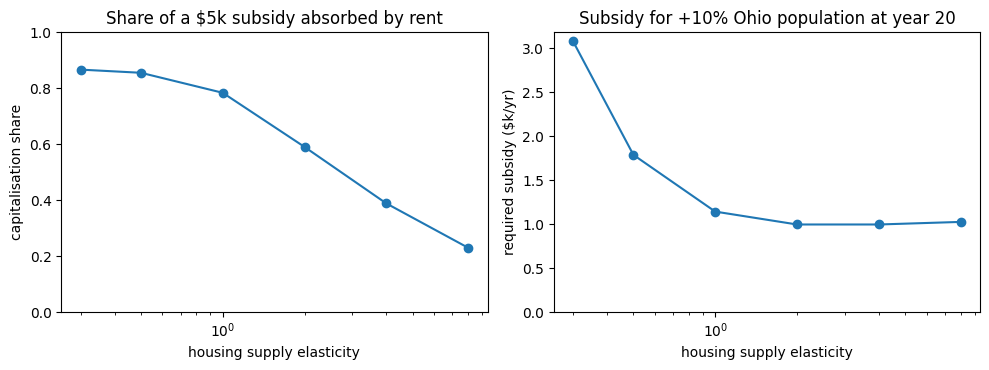

,required subsidy s* ($k/yr)
0.3,3.08
0.5,1.79
1.0,1.14
2.0,1.00
4.0,1.00
8.0,1.03


In [10]:
req = pd.Series({eps: required_subsidy_for_target(Params(n_years=T, elasticity=eps, policy_state=ohio),
                                                  init, TARGET, T, n_seeds=N_SEEDS)
                 for eps in elasticities}, name="required subsidy s* ($k/yr)")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
kappa5 = measures[measures["subsidy ($k/yr)"] == 5]
ax[0].plot(kappa5["elasticity"], kappa5["capitalisation share"], "o-")
ax[0].set(xscale="log", xlabel="housing supply elasticity", ylabel="capitalisation share",
          title="Share of a $5k subsidy absorbed by rent", ylim=(0, 1))
ax[1].plot(req.index, req.values, "o-")
ax[1].set(xscale="log", xlabel="housing supply elasticity", ylabel="required subsidy ($k/yr)",
          title=f"Subsidy for +{TARGET:.0%} Ohio population at year {T}", ylim=(0, None))
plt.tight_layout(); plt.show()
req.round(2).to_frame()

**Reading this (the migration cost is calibrated, but the other parameters are still placeholders, so the direction matters more than the sizes).** The more inelastic the housing supply, the larger the share of a subsidy that rent absorbs and the smaller the population gain, so a larger subsidy is needed for the same target. The required subsidy falls steeply as $\varepsilon$ rises from 0.3 to about 1.5 and then flattens. The target is a modest +10%, and results at a different horizon or target will differ, which the full sweep will examine.

### 5.2 Experimental design

All experiments use Ohio as the policy state, a 20-year horizon and 20 random seeds per scenario, with the subsidy run and its no-subsidy control sharing seeds. Parameters not being varied keep the defaults in `src/params.py`. The configuration lives in `utils/run_sweeps.py`, results are cached as CSV files in `data/results/`, and set `RECOMPUTE = True` below to regenerate them (about 3 minutes).

| Experiment | What varies | Outcome |
|---|---|---|
| Main grid | elasticity (10 values, 0.3 to 8) $\times$ subsidy (9 values, 1 to 12 $k/yr) | gain $G$ (with standard error) and capitalisation share $\kappa$ |
| Required subsidy | elasticity $\times$ target gain (+2%, +5%, +10%, +20%) | $s^*$, repeated over 5 independent seed batches to show simulation noise |
| Sensitivity | migration cost (0, 6, 8, 10, 20), tie strength (0 to 15), choice sensitivity $\beta$, share reconsidering each year, and horizon (10, 20, 40 years), each across 6 elasticities | $s^*$ for the +10% target |

The +2% target is close to the effect of real place-based scholarship programmes (about +1.7% population; Bartik and Sotherland 2015). Migration cost and tie strength are two of the four manipulated parameters, and the default migration cost of 8 is calibrated in section 4.3. $\beta$ and the share reconsidering are fixed constants whose placeholder values are included in the sensitivity analysis because they are not yet justified.

In [11]:
from utils.run_sweeps import compute_all
from utils import plots

RECOMPUTE = False   # set True to rerun every experiment (about 3 minutes)
results = compute_all(recompute=RECOMPUTE, verbose=False)
FIG = ROOT / "notebooks" / "figures"
FIG.mkdir(exist_ok=True)
{name: len(df) for name, df in results.items()}

{'gain_kappa_grid': 90,
 'required_subsidy': 40,
 'sensitivity_migration_cost': 30,
 'sensitivity_tie_strength': 30,
 'sensitivity_beta': 18,
 'sensitivity_move_fraction': 18,
 'sensitivity_horizon': 18}

## 6. Results

### 6.1 Population gain and capitalisation share

Both measures are taken at year 20 relative to the no-subsidy control. Across the grid, the gain ranges from 0.03 to 5.26 times Ohio's initial population, with standard errors of at most 0.02.

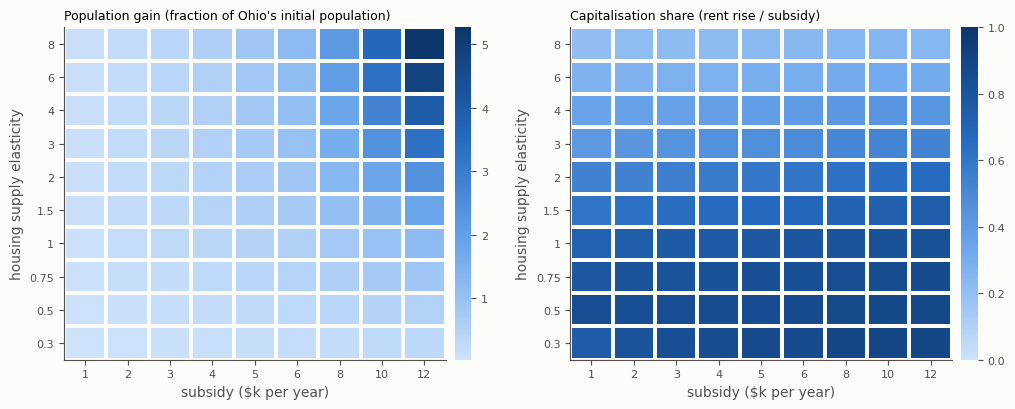

In [12]:
plots.plot_gain_kappa(results["gain_kappa_grid"], FIG / "gain_kappa.png");

The capitalisation share falls steadily as housing supply becomes more elastic, from about 0.8 to 0.9 at $\varepsilon = 0.3$ (most of the subsidy absorbed by rent) to about 0.2 at $\varepsilon = 8$. The population gain moves the opposite way and grows faster than linearly with the subsidy: at $\varepsilon = 8$ it rises from about 0.1 at a subsidy of 1 to about 5 at a subsidy of 12.

### 6.2 Subsidy required for a target gain

,+2% target,+5% target,+10% target,+20% target
elasticity,,,,
0.30,0.56,1.45,3.02,6.63
0.50,0.37,0.89,1.80,3.77
0.75,0.27,0.67,1.32,2.63
1.00,0.24,0.58,1.13,2.21
1.50,0.22,0.53,1.03,1.95
2.00,0.23,0.52,0.99,1.84
3.00,0.22,0.53,0.99,1.81
4.00,0.21,0.52,0.98,1.78
6.00,0.23,0.53,1.00,1.80


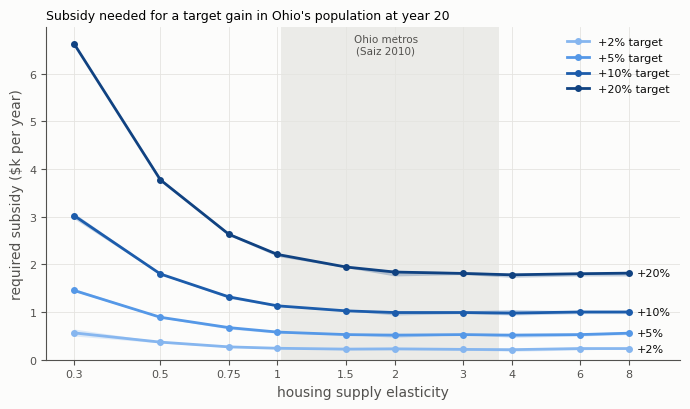

In [13]:
plots.plot_required_subsidy(results["required_subsidy"], FIG / "required_subsidy.png")
tbl = results["required_subsidy"].pivot(index="elasticity", columns="target", values="s_mean").round(2)
tbl.columns = [f"+{t:.0%} target" for t in tbl.columns]
tbl

The required subsidy falls steeply as supply becomes more elastic and then **flattens completely**. For the +10% target it drops from about 3.0 at $\varepsilon = 0.3$ to 1.8 at 0.5, 1.1 at 1 and 1.0 at 2, and stays at 1.0 from $\varepsilon = 2$ to 8. The shaded bands show the spread over five independent seed batches, which is small (at most 0.15), so the plateau is not noise. Most of the benefit of more elastic housing supply therefore arrives early, below about $\varepsilon = 1.5$. This matters for Ohio: its metro areas have elasticities of about 1.0 to 3.7 (Saiz 2010, Table VI; shaded in the figure), which lies almost entirely on the plateau, whereas coastal metros (0.6 to 0.8) would need about 1.3 to 1.8. The required subsidy grows roughly in proportion to the target: at $\varepsilon = 1$ the four targets need about 0.24, 0.58, 1.1 and 2.2. The absolute values (about 0.2 to 3 \$k per year, against a median Ohio household income of about \$45k) depend on parameters that are not all calibrated, as the next section shows.

### 6.3 Sensitivity to other parameters

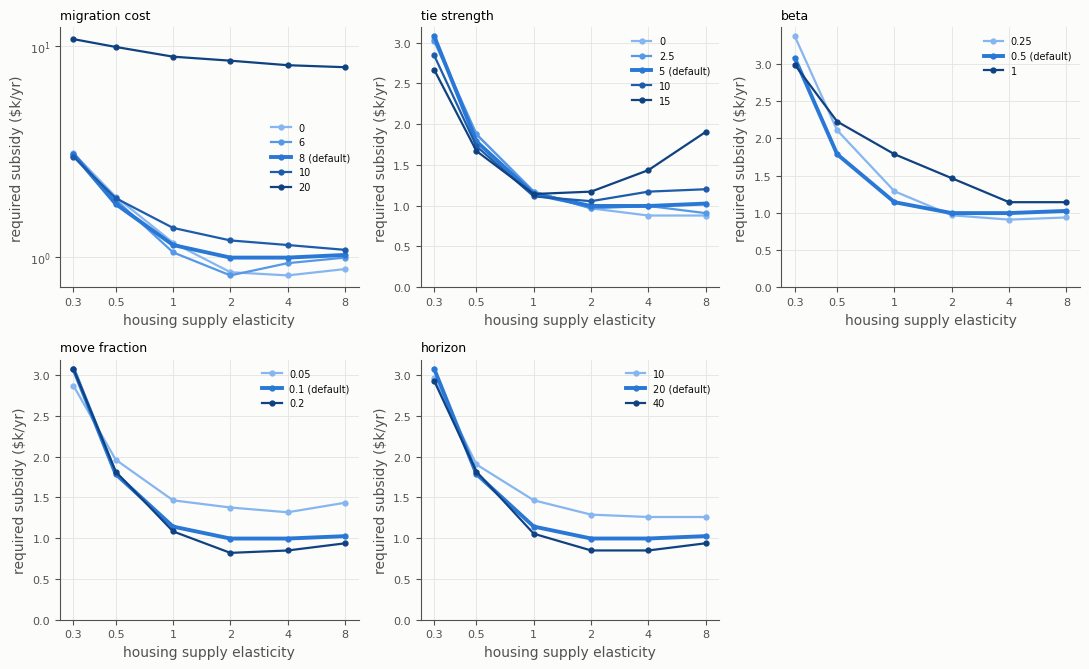

In [14]:
from utils.run_sweeps import SENSITIVITY
names = ["migration_cost", "tie_strength", "beta", "move_fraction", "horizon"]
tables = {n: results[f"sensitivity_{n}"] for n in names}
defaults = {"migration_cost": Params().migration_cost, "tie_strength": Params().tie_strength,
            "beta": Params().beta, "move_fraction": Params().move_fraction, "horizon": 20}
plots.plot_sensitivity(tables, defaults, save_path=FIG / "sensitivity.png");

**The shape is mostly robust, but the size is not.** In nearly every panel the required subsidy falls steeply and then flattens. The absolute level depends strongly on migration cost (a cost of 20 raises the required subsidy to about 8 to 11, note the log axis), and on $\beta$ and the share of agents reconsidering each year (for $\varepsilon \ge 2$ it is about 0.9 to 1.0 at $\beta = 0.25$ against 1.1 to 1.5 at $\beta = 1$, and about 1.3 to 1.4 when only 5% reconsider against 0.8 to 0.9 when 20% do). The horizon shifts the plateau: about 1.26 at 10 years, 1.0 at 20 and 0.85 at 40 years, so a shorter horizon needs about 26% more subsidy and a longer one about 15% less. The ordering across elasticities is unchanged.

**Migration cost changes how much elasticity matters.** At high migration cost the subsidy mostly has to pay for the move itself, so elasticity matters less in relative terms (a fall of about 26%, from 10.8 to 7.9, at a cost of 20, against about 67%, from 3.1 to 1.0, at the calibrated cost of 8). The calibrated values of 6 and 8 and the old placeholder of 10 give similar plateaus (1.0, 1.0 and 1.1).

**Remaining unexplained behaviour.** At the default parameters the curve is flat beyond $\varepsilon \approx 2$, but under some settings it turns upward at high elasticity: with strong social ties (tie strength 10 and 15, rising to 1.2 and 1.9 at $\varepsilon = 8$), and mildly at low migration cost (0.82 at $\varepsilon = 2$ rising to 1.00 at $\varepsilon = 8$ for a cost of 6) or when few agents reconsider. A possible explanation, not yet tested, is that strong ties pull population towards larger states, so that Ohio's no-subsidy control run shrinks more when rent does not respond, which changes what the gain is measured against. This should be investigated before the report states the plateau as a general result.

## 7. Discussion and limitations

*To be completed.* Points to cover: the baseline check does not reproduce observed migration (section 4.2, rank correlation about $-0.7$), which is treated as a stated limitation; results are scenario comparisons rather than forecasts; wages are fixed and housing supply is a single elasticity parameter, whereas the empirical elasticities are long-run; agents are generic residents with no age or education, and household-level medians stand in for all of them; only the migration cost is calibrated. Details are in `report/notes.md`.

## 8. Interactive demonstration

The sliders below re-run the model for Ohio (20 seeds, 20 years) with and without the subsidy. Shaded bands show the 10th to 90th percentile across seeds. **Run the cell in Jupyter or VS Code**, because the sliders do not work in a static export (the preview below shows the default setting).

Suggested walk-through:
1. Leave migration cost and tie strength at their defaults, set the subsidy to 5, and move **elasticity** from 0.3 to 8. At low elasticity rent rises sharply and absorbs most of the subsidy (capitalisation share near 0.9), so the population gain is small. At high elasticity rent barely moves (share near 0.2) and the gain is large.
2. Set elasticity to 1 and raise **migration cost**. Fewer agents move, so a given subsidy attracts fewer people.
3. Choose a target gain and press **Find required subsidy**. This reruns the bisection search behind section 6.2 for the current slider settings.

In [15]:
from utils.demo import interactive_demo, plot_scenario, scenario_summary, animate_flows

interactive_demo(init)

**Static preview** (subsidy 5, elasticity 1, default migration cost and tie strength):

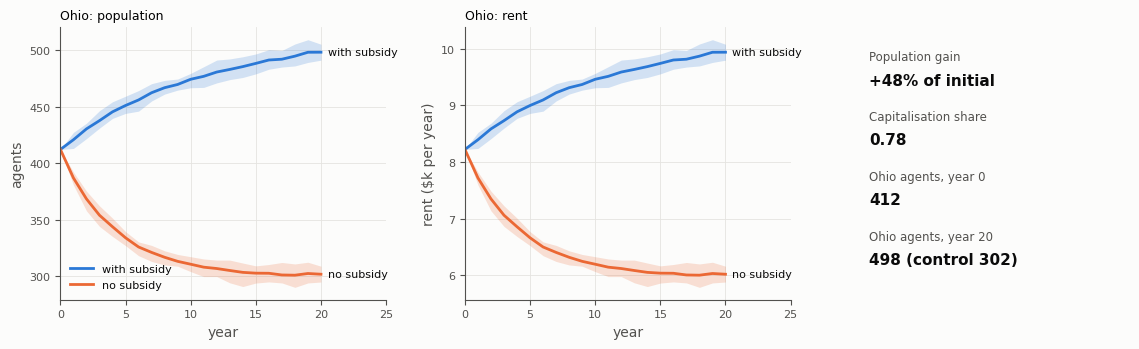

In [16]:
preview = Params(policy_state=ohio, subsidy=5.0, elasticity=1.0)
fig = plot_scenario(scenario_summary(preview, init), preview, init)
fig.savefig(FIG / "scenario_preview.png", dpi=150)
plt.show()

### 8.1 Animation of flows between states

One run (seed 0) with the same subsidy of \$5k per year in Ohio, under inelastic (left) and elastic (right) housing supply. Each modelled state is tinted by its rent, arrows show the largest yearly flows between states (thicker means more agents), and Ohio has a dark outline. Under inelastic supply Ohio's rent climbs faster for a smaller gain in population.

In [17]:
scen_base = Params(policy_state=ohio, n_years=20, subsidy=5.0)
anim, fig_anim, _ = animate_flows(
    [("Inelastic housing supply (elasticity 0.5)", replace(scen_base, elasticity=0.5)),
     ("Elastic housing supply (elasticity 3)", replace(scen_base, elasticity=3.0))],
    init, path=FIG / "flows.gif")
plt.close(fig_anim)

![Flows between states under inelastic and elastic housing supply](figures/flows.gif)